In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import sys
sys.path.insert(0, r"c:\ProjectsDannyDavis\VolatilityPredictionProject\utils")

import API_Keys
from File_Paths import raw_data_filepath, candidate_model_filepath
from file_reader import read_file
from returns_utils import append_returns
import obb_functions
import plotting_functions as plot_func

from arch.univariate import arch_model
from itertools import permutations

#### Model Iterations
Running iterations over permutations of p and q

In [3]:
SAP500 = read_file(raw_data_filepath, r"SP500_price_data.parquet")
SAP500 = SAP500[['simple_return']]*100

In [4]:
perms = list(permutations(range(21),2))

In [5]:
model_variants = {}

for i in perms:
    model_variants[f"GARCH{i}"] = i

In [6]:
# variants for x,x models (not covered in permutations)

for i in range(21):
    model_variants[f"GARCH({i},{i})"] = (i,i)

In [7]:
results = {}

for model, params in model_variants.items():
    if params[0]==0:
        continue
    bic = arch_model(SAP500, mean='Zero', vol='GARCH', p=params[0], q=params[1]).fit().bic
    if params[1]==0:
        model = f"ARCH({params[0]})"

    results[model] = {'p':params[0], 'q':params[1], 'bic':bic}

Iteration:      1,   Func. Count:      4,   Neg. LLF: 9000.08971188706
Iteration:      2,   Func. Count:     11,   Neg. LLF: 5952.723261438452
Iteration:      3,   Func. Count:     15,   Neg. LLF: 5733.983941217606
Iteration:      4,   Func. Count:     19,   Neg. LLF: 5701.769159022884
Iteration:      5,   Func. Count:     22,   Neg. LLF: 5701.753808945093
Iteration:      6,   Func. Count:     25,   Neg. LLF: 5701.7537485805815
Iteration:      7,   Func. Count:     27,   Neg. LLF: 5701.753748580672
Optimization terminated successfully    (Exit mode 0)
            Current function value: 5701.7537485805815
            Iterations: 7
            Function evaluations: 27
            Gradient evaluations: 7
Iteration:      1,   Func. Count:      6,   Neg. LLF: 23368.88015154064
Iteration:      2,   Func. Count:     17,   Neg. LLF: 7708.461124616971
Iteration:      3,   Func. Count:     24,   Neg. LLF: 7598.409843869159
Iteration:      4,   Func. Count:     30,   Neg. LLF: 5213.958651315171


In [8]:
results_df = pd.DataFrame(results).T

In [ ]:
# saving results to reference later

# import os
# results_df.to_parquet(os.path.join(candidate_model_filepath,r"candidate_model_results.parquet"))

#### Results Analysis

In [10]:
results_df = read_file(candidate_model_filepath, r"candidate_model_results.parquet")

In [11]:
results_df

,p,q,bic
ARCH(1),1.0,0.0,11420.107064
"GARCH(1, 2)",1.0,2.0,10438.283825
"GARCH(1, 3)",1.0,3.0,10446.583608
"GARCH(1, 4)",1.0,4.0,10454.883392
"GARCH(1, 5)",1.0,5.0,10463.183175
...,...,...,...
"GARCH(16,16)",16.0,16.0,10658.699321
"GARCH(17,17)",17.0,17.0,10675.298887
"GARCH(18,18)",18.0,18.0,10691.728634
"GARCH(19,19)",19.0,19.0,10705.042651


In [12]:
results_df.sort_values('bic', ascending=True)

,p,q,bic
"GARCH(1,1)",1.0,1.0,10429.984042
"GARCH(2, 1)",2.0,1.0,10434.471941
"GARCH(1, 2)",1.0,2.0,10438.283825
"GARCH(2,2)",2.0,2.0,10439.295017
"GARCH(3, 1)",3.0,1.0,10442.771724
...,...,...,...
"GARCH(20, 19)",20.0,19.0,10713.342434
ARCH(3),3.0,0.0,10719.691514
"GARCH(20,20)",20.0,20.0,10719.783004
ARCH(2),2.0,0.0,10962.979387


In [13]:
results_df_piv = results_df.pivot(columns='q', index='p', values='bic').sort_index(ascending=True).T.sort_index(ascending=True).T.round(2) 

In [14]:
results_df_piv

q,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,18.0,19.0,20.0
p,,,,,,,,,,,,,,,,,,,,,
1.0,11420.11,10429.98,10438.28,10446.58,10454.88,10463.18,10471.45,10479.48,10487.57,10495.42,...,10510.40,10517.54,10525.27,10533.07,10540.50,10548.63,10556.23,10564.21,10571.89,10579.78
2.0,10962.98,10434.47,10439.30,10447.59,10455.89,10466.74,10474.47,10482.34,10490.46,10496.75,...,10512.33,10518.22,10526.52,10534.30,10542.15,10550.31,10557.95,10566.05,10573.34,10581.49
3.0,10719.69,10442.77,10447.26,10455.56,10463.86,10472.16,10480.09,10488.39,10495.98,10504.28,...,10519.51,10525.24,10533.54,10541.11,10549.05,10557.12,10564.88,10572.92,10580.40,10588.50
4.0,10607.67,10451.07,10454.92,10463.22,10470.51,10478.81,10485.29,10493.59,10501.89,10510.14,...,10525.76,10530.89,10539.19,10546.94,10555.14,10563.11,10571.16,10578.93,10586.11,10593.97
5.0,10554.33,10459.37,10463.22,10471.52,10478.81,10487.11,10493.54,10501.84,10510.14,10518.37,...,10534.06,10539.19,10547.49,10555.09,10563.32,10571.35,10579.46,10587.07,10594.41,10602.31
6.0,10514.88,10467.67,10471.52,10479.82,10487.11,10495.41,10500.85,10509.15,10517.45,10525.68,...,10542.21,10547.78,10556.05,10561.99,10570.56,10578.86,10586.89,10595.11,10601.98,10608.49
7.0,10506.73,10475.97,10479.82,10490.17,10495.41,10503.71,10509.15,10517.45,10525.75,10533.98,...,10550.51,10555.79,10564.35,10570.29,10578.85,10587.15,10595.45,10603.41,10610.28,10616.77
8.0,10496.23,10484.27,10488.11,10496.41,10503.71,10512.01,10517.45,10525.75,10534.05,10542.28,...,10558.80,10563.38,10571.68,10578.05,10586.67,10594.97,10603.27,10611.43,10618.24,10625.00
9.0,10497.43,10492.57,10496.41,10504.71,10512.01,10520.31,10525.75,10534.05,10542.35,10550.58,...,10567.10,10571.55,10579.85,10586.22,10594.52,10602.82,10611.12,10619.41,10626.54,10633.30


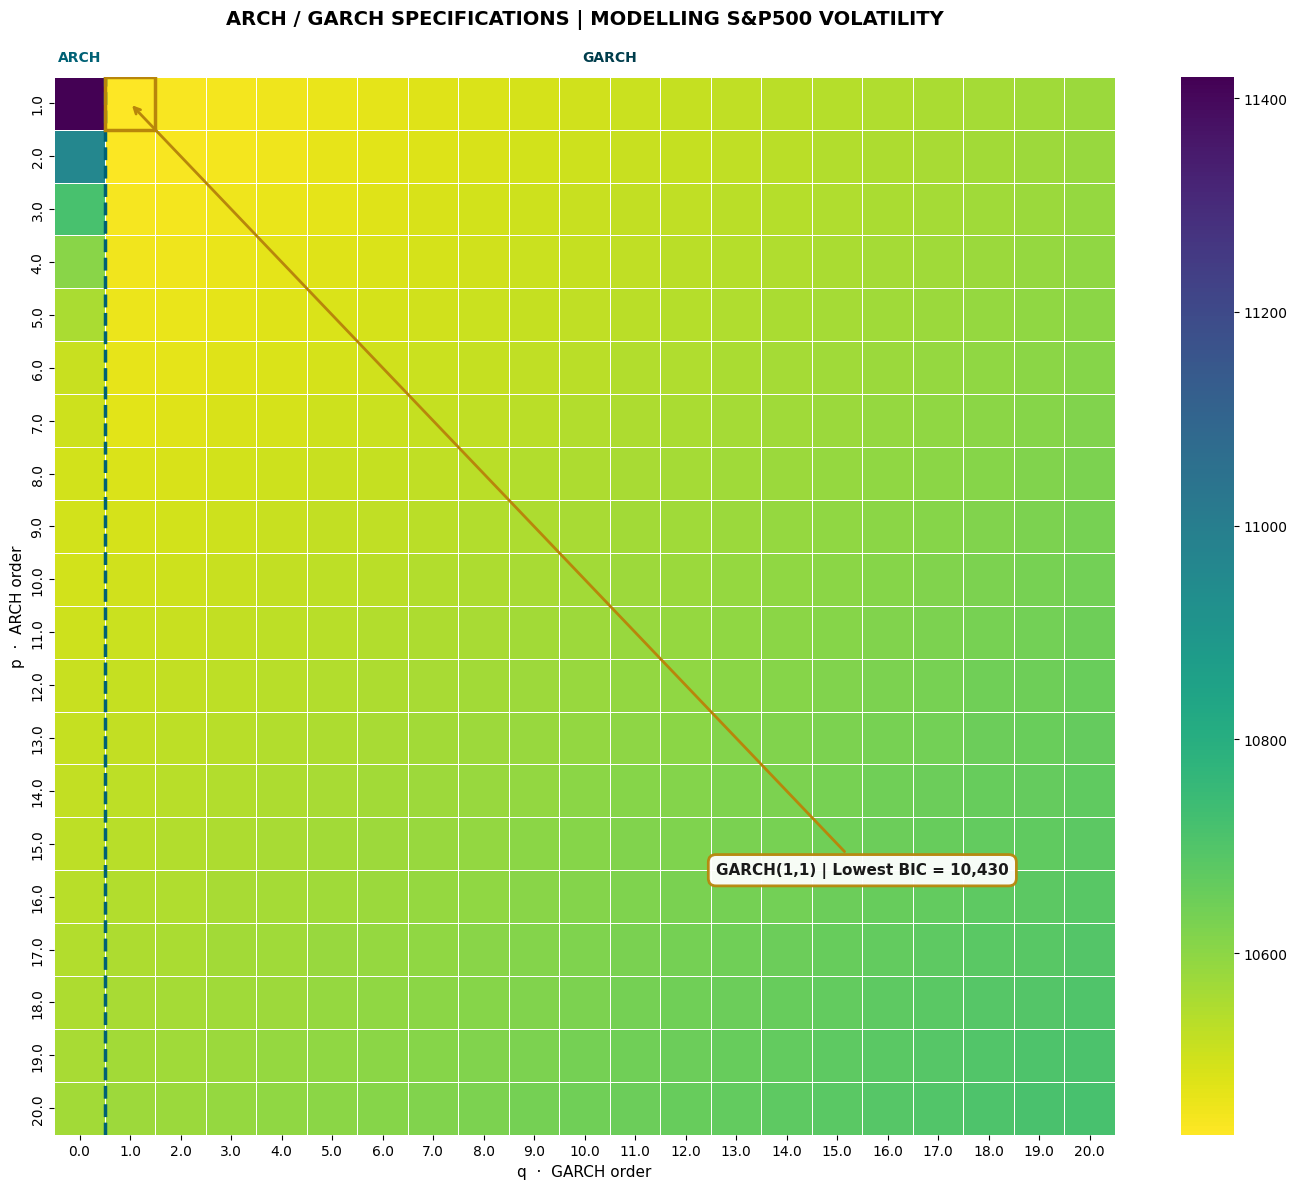

In [15]:
fig, ax = plot_func.plot_heatmap(
    results_df_piv,
    title='ARCH / GARCH SPECIFICATIONS | MODELLING S&P500 VOLATILITY',
    xlabel='q  ·  GARCH order',
    ylabel='p  ·  ARCH order',
    figsize=(14, 12),
    annot=False,
    cmap='viridis_r',
    arch_col_split=True,
    dark=False
)

# Gold box around the winning cell: GARCH(1,1)
ax.add_patch(mpatches.Rectangle(
    (1, 0), 1, 1,
    linewidth=2.5, edgecolor="#B8860B", facecolor="none", zorder=5
))

# Annotation anchored in lower-right (dark green bg) — white box stands out
ax.annotate(
    "GARCH(1,1) | Lowest BIC = 10,430",
    xy=(1.5, 0.5),
    xytext=(16, 15),
    fontsize=11, color="#1a1a1a", fontweight="bold",
    ha="center", va="center",
    arrowprops=dict(arrowstyle="->", color="#B8860B", lw=2.0),
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#B8860B", alpha=0.95, linewidth=2)
)

plt.tight_layout()
plt.show()